In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from pathlib import Path

# set the style for the plots
plt.style.use('seaborn-v0_8-paper')

OUT_DIR = 'figures/'
# Create the output directory if it doesn't exist
if not os.path.exists(OUT_DIR):
    os.makedirs(OUT_DIR)

# GPT4o for citing sentence detection

In [1]:
# GPT4o performance for missing reference detection by percentange of references found for three different papers
with_reference_markers = [0.16, 0.51, 0.05]
no_reference_markers = [0.05, 0.2, 0.03]

# Create a bar chart with large font size labels
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(['Paper 1 (new)', 'Paper 2 (old, popular)', 'Paper 3 (old, unpopular)'], with_reference_markers, label='With Reference Markers', alpha=0.7)
ax.bar(['Paper 1 (new)', 'Paper 2 (old, popular)', 'Paper 3 (old, unpopular)'], no_reference_markers, label='No Reference Markers', alpha=0.7)

# Add labels and title
ax.set_ylabel('Percentage of References Found', fontsize=16)
ax.set_title('GPT4o Performance for Missing Reference Detection', fontsize=18)
ax.legend(fontsize=14)
# Y-axis limits
ax.set_ylim(0, 1.0)
# bigger font size for better readability
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()

# Save the figure
fig.savefig(OUT_DIR + 'gpt4o_performance_missing_reference_detection.png', dpi=300, bbox_inches='tight', metadata={'CreationDate': None})

NameError: name 'plt' is not defined

# Gemini 2.0 Flash Fine-Tuned for Citing Sentence Detection

## Training

In [3]:
training_acc_path = Path('../data/gemini_citsent_train/Accuracy.csv')

# Load the training accuracy data
training_acc = pd.read_csv(training_acc_path)

training_acc.describe()

,TimeSeries ID,train
count,593.000000,593.000000
mean,297.000000,0.968154
std,171.328632,0.022416
min,1.000000,0.803455
25%,149.000000,0.965927
50%,297.000000,0.974382
75%,445.000000,0.976361
max,593.000000,0.980020


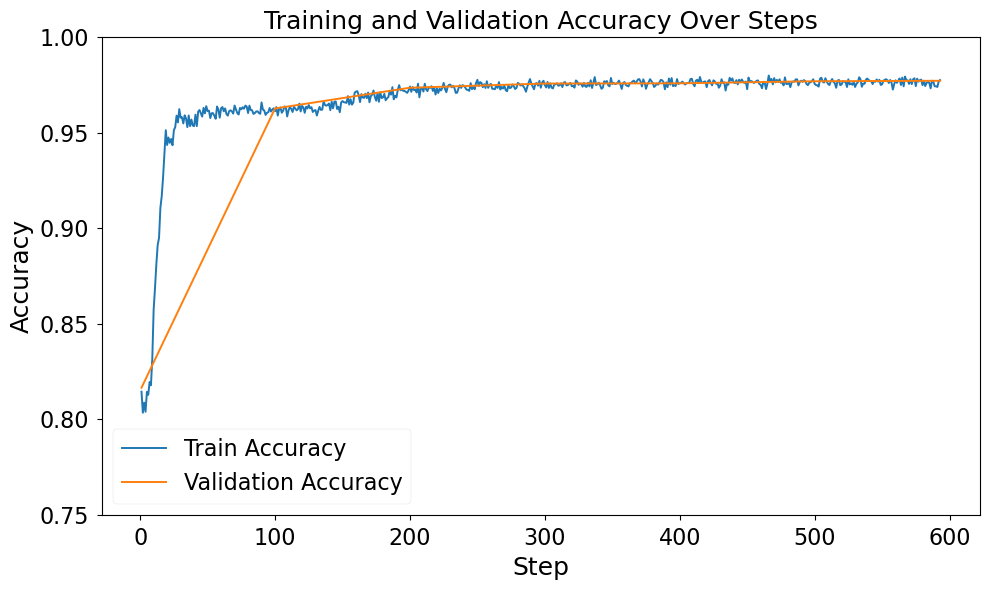

In [14]:
# Plot the training accuracy for both train and validation sets
# Keep in mind that not every epoch has a validation accuracy, so we will just draw the train accuracy for every epoch and validation accuracy only for those epochs where it was calculated.

# Convert 'undefined' values to NaN for proper handling
training_acc['validation'] = pd.to_numeric(training_acc['validation'], errors='coerce')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(training_acc['TimeSeries ID'], training_acc['train'], label='Train Accuracy', marker='x', linestyle='-')
# Plot validation accuracy with dropna=False to ensure continuous line between valid points
valid_mask = ~training_acc['validation'].isna()
if valid_mask.any():
    # Get only the rows with validation data
    valid_points = training_acc[valid_mask]
    ax.plot(valid_points['TimeSeries ID'], valid_points['validation'],
            label='Validation Accuracy', marker='x', linestyle='-')
# Add labels and title
ax.set_xlabel('Step', fontsize=18)
ax.set_ylabel('Accuracy', fontsize=18)
ax.set_title('Training and Validation Accuracy Over Steps', fontsize=18)

# Add a legend
ax.legend(fontsize=16)
# Set y-axis limits
ax.set_ylim(0.75, 1.0)
# Set font size for x and y ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Show the plot
plt.tight_layout()
plt.show()
# Save the figure
fig.savefig(OUT_DIR + 'gemini2_flash_training_validation_accuracy.png', dpi=300, bbox_inches='tight', metadata={'CreationDate': None})

In [7]:
training_loss_path = Path('../data/gemini_citsent_train/Loss.csv')
# Load the training loss data
training_loss = pd.read_csv(training_loss_path)
training_loss.describe()

,TimeSeries ID,train
count,593.000000,593.000000
mean,297.000000,0.089677
std,171.328632,0.207084
min,1.000000,0.044609
25%,149.000000,0.051150
50%,297.000000,0.054139
75%,445.000000,0.068692
max,593.000000,1.946810


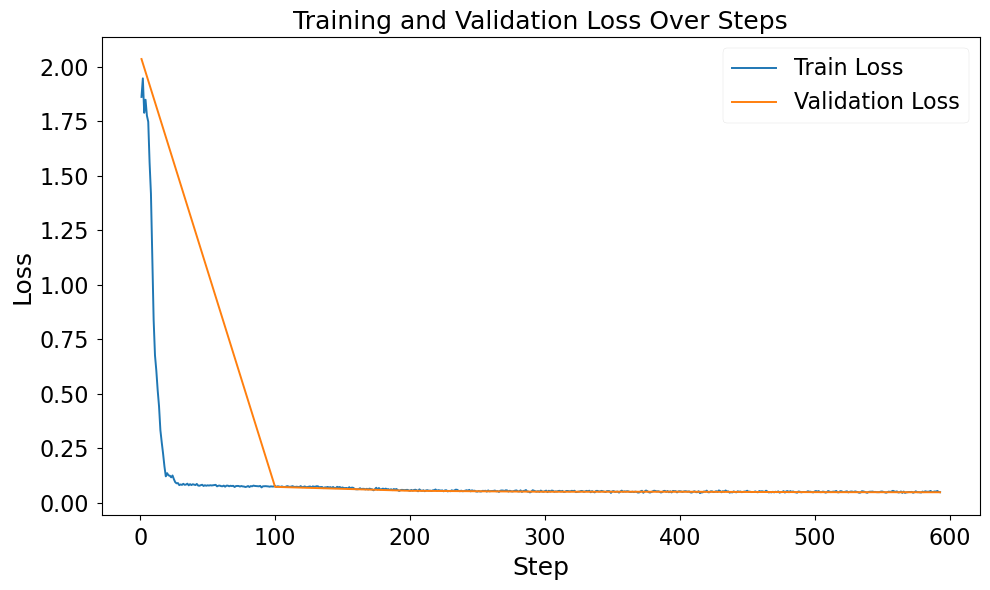

In [15]:
# Plot the training loss for both train and validation sets
# Keep in mind that not every epoch has a validation loss, so we will handle it similarly to accuracy

# Convert 'undefined' values to NaN for proper handling
training_loss['validation'] = pd.to_numeric(training_loss['validation'], errors='coerce')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(training_loss['TimeSeries ID'], training_loss['train'], label='Train Loss', marker='x', linestyle='-')
# Plot validation loss with dropna=False to ensure continuous line between valid points
valid_mask = ~training_loss['validation'].isna()
if valid_mask.any():
    # Get only the rows with validation data
    valid_points = training_loss[valid_mask]
    ax.plot(valid_points['TimeSeries ID'], valid_points['validation'],
            label='Validation Loss', marker='x', linestyle='-')
# Add labels and title
ax.set_xlabel('Step', fontsize=18)
ax.set_ylabel('Loss', fontsize=18)
ax.set_title('Training and Validation Loss Over Steps', fontsize=18)

# Add a legend
ax.legend(fontsize=16)
# Set font size for x and y ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Show the plot
plt.tight_layout()
plt.show()
# Save the figure
fig.savefig(OUT_DIR + 'gemini2_flash_training_validation_loss.png', dpi=300, bbox_inches='tight', metadata={'CreationDate': None})


## Confusion Matrix

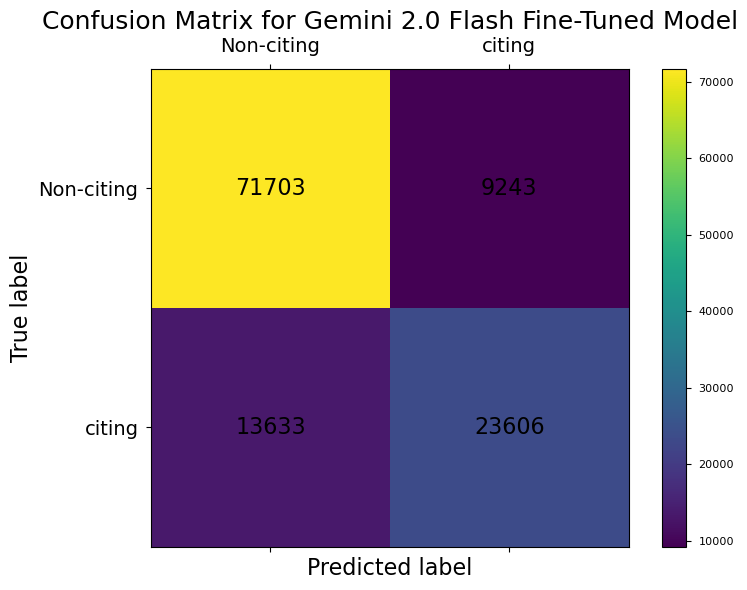

In [19]:
cm = [[71703, 9243],
      [13633, 23606]]

# convert to numpy array for plotting
cm = np.array(cm)

# Plot the confusion matrix with numbers on squares
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(cm)
# Add color bar
plt.colorbar(cax)
# Add text annotations in the squares
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center', fontsize=16)
# Add labels and title
ax.set_title('Confusion Matrix for Gemini 2.0 Flash Fine-Tuned Model', fontsize=18)
ax.set_ylabel('True label', fontsize=16)
ax.set_xlabel('Predicted label', fontsize=16)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-citing', 'citing'], fontsize=14)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Non-citing', 'citing'], fontsize=14)
plt.tight_layout()
plt.show()
# Save the figure
fig.savefig(OUT_DIR + 'gemini-citsent-confusion-matrix.png', dpi=300, bbox_inches='tight', metadata={'CreationDate': None})
